In [4]:
!nvidia-smi

Fri Mar 27 15:08:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.07                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   58C    P0             16W /   60W |     100MiB /   4096MiB |     18%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [1]:
%pip install torch-geometric

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from typing import Dict

Note: you may need to restart the kernel to use updated packages.


d:\Programming\KinetoCheck\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


============= UI-PRMD Kinect Skeleton Graph (22 Joints) =============
Canonical model order used in this notebook (0-indexed):
0: Waist, 1: Spine, 2: Chest, 3: Neck, 4: Head, 5: Head tip
6: L Collar, 7: L Upper Arm, 8: L Forearm, 9: L Hand
10: R Collar, 11: R Upper Arm, 12: R Forearm, 13: R Hand
14: L Upper Leg, 15: L Lower Leg, 16: L Foot, 17: L Toes
18: R Upper Leg, 19: R Lower Leg, 20: R Foot, 21: R Toes

Raw UI-PRMD Kinect file order (documented by dataset):
Head, Head tip, Neck, Chest, Spine, Waist, Left Collar, Right Collar,
Left Upper Arm, Right Upper Arm, Left Forearm, Right Forearm, Left Hand, Right Hand,
Left Upper Leg, Right Upper Leg, Left Lower Leg, Right Lower Leg, Left Foot, Right Foot,
Left Leg Toes, Right Leg Toes

Coordinates are stored as YXZ in raw files (Y=height).
In preprocessing, we convert YXZ -> XYZ and remap joints into canonical model order.

In [2]:
UIPRMD_EDGES = [
    # Torso / Spine (0 to 5)
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5),

    # Left Arm (Branching from Chest: 2)
    (2, 6), (6, 7), (7, 8), (8, 9),

    # Right Arm (Branching from Chest: 2)
    (2, 10), (10, 11), (11, 12), (12, 13),

    # Left Leg (Branching from Waist: 0)
    (0, 14), (14, 15), (15, 16), (16, 17),

    # Right Leg (Branching from Waist: 0)
    (0, 18), (18, 19), (19, 20), (20, 21)
]

In [3]:
def build_edge_index(num_nodes: int = 22, edges: list = None) -> torch.Tensor:
    if edges is None:
        edges = UIPRMD_EDGES

    valid_edges = [(s, d) for s, d in edges if s < num_nodes and d < num_nodes]

    # Bidirectional
    src = [e[0] for e in valid_edges] + [e[1] for e in valid_edges]
    dst = [e[1] for e in valid_edges] + [e[0] for e in valid_edges]

    # Add self-loops
    src += list(range(num_nodes))
    dst += list(range(num_nodes))

    return torch.tensor([src, dst], dtype=torch.long)

In [4]:
class SpatialGATBlock(nn.Module):
    """
    Spatial Graph Attention over skeleton nodes.
    Processes all T timesteps independently.
    """

    def __init__(self, in_channels: int, out_channels: int,
                 num_heads: int = 4, dropout: float = 0.3):
        super().__init__()
        self.gat = GATConv(
            in_channels,
            out_channels // num_heads,
            heads=num_heads,
            dropout=dropout,
            concat=True,
            add_self_loops=False
        )
        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B*T*J, C_in) node features
            edge_index: (2, E) edge indices

        Returns:
            out: (B*T*J, C_out) features
        """
        out = self.gat(x, edge_index)
        out = self.bn(out)
        return F.relu(out)

In [5]:

class TemporalConvBlock(nn.Module):
    """
    Temporal 1D convolution on joint features.
    Processes temporal dynamics for each joint independently.
    """

    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size: int = 3, dilation: int = 1):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B*J, C_in, T) temporal sequence per joint

        Returns:
            out: (B*J, C_out, T)
        """
        out = self.conv(x)
        out = self.bn(out)
        return F.relu(out)

In [6]:
class PyramidBranch(nn.Module):
    """
    Single pyramid branch for one temporal scale.
    Combines spatial attention + temporal convolution.
    """

    def __init__(self, in_channels: int, hidden_channels: int,
                 num_heads: int = 4, num_joints: int = 17):
        super().__init__()

        self.num_joints = num_joints
        self.edge_index = build_edge_index(num_joints)

        # Spatial-temporal layers
        self.spatial1 = SpatialGATBlock(in_channels, hidden_channels,
                                       num_heads=num_heads)
        self.temporal1 = TemporalConvBlock(hidden_channels, hidden_channels,
                                          kernel_size=3)

        self.spatial2 = SpatialGATBlock(hidden_channels, hidden_channels,
                                       num_heads=num_heads)
        self.temporal2 = TemporalConvBlock(hidden_channels, hidden_channels,
                                          kernel_size=3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T, J, C) batch of sequences

        Returns:
            out: (B, T, J, C) processed features
        """
        B, T, J, C = x.shape

        # Reshape for spatial processing: (B*T*J, C)
        x_flat = x.reshape(B * T * J, C)

        # Repeat edge index for batch
        edge_index = self.edge_index.to(x.device)

        # Spatial attention
        x_spatial = self.spatial1(x_flat, edge_index)  # (B*T*J, C)

        # Reshape for temporal processing: (B*J, C, T)
        x_temp = x_spatial.reshape(B, T, J, -1)
        x_temp = x_temp.permute(0, 2, 3, 1).reshape(B * J, -1, T)

        # Temporal convolution
        x_temp = self.temporal1(x_temp)  # (B*J, C, T)

        # Reshape back: (B*T*J, C)
        x_temp = x_temp.reshape(B, J, -1, T).permute(0, 3, 1, 2)
        x_temp = x_temp.reshape(B * T * J, -1)

        # Second spatial layer
        x_spatial = self.spatial2(x_temp, edge_index)

        # Second temporal layer
        x_temp = x_spatial.reshape(B, T, J, -1)
        x_temp = x_temp.permute(0, 2, 3, 1).reshape(B * J, -1, T)
        x_temp = self.temporal2(x_temp)

        # Back to (B, T, J, C)
        x_out = x_temp.reshape(B, J, -1, T).permute(0, 3, 1, 2)

        return x_out

In [7]:
class MultiScaleFusion(nn.Module):
    """
    Fuses features from different temporal scales using attention.
    """

    def __init__(self, channels: int, num_scales: int = 4):
        super().__init__()
        self.num_scales = num_scales

        # Cross-scale attention
        self.attention = nn.MultiheadAttention(
            channels,
            num_heads=4,
            batch_first=True,
            dropout=0.1
        )

        # Fusion weights (learnable)
        self.scale_weights = nn.Parameter(
            torch.ones(num_scales) / num_scales
        )

    def forward(self, pyramid: Dict[int, torch.Tensor]) -> torch.Tensor:
        """
        Args:
            pyramid: Dict mapping scale -> (B, T_scale, J, C) features

        Returns:
            fused: (B, T_max, J, C) fused features at finest scale
        """
        scales = sorted(pyramid.keys())
        features_list = []

        # Upsample coarser features to finest scale
        finest_t = pyramid[scales[0]].shape[1]

        for scale in scales:
            feat = pyramid[scale]  # (B, T_scale, J, C)
            B, T_scale, J, C = feat.shape

            if scale > 1:
                # Upsample: (B, T_scale, J, C) -> (B, T_max, J, C)
                feat = self._upsample_temporal(feat, finest_t)

            features_list.append(feat)

        # Stack features: (num_scales, B, T_max, J, C)
        stacked = torch.stack(features_list)

        # Apply learned weights
        weights = F.softmax(self.scale_weights, dim=0)
        weighted = (stacked * weights.view(-1, 1, 1, 1, 1)).sum(dim=0)

        return weighted

    @staticmethod
    def _upsample_temporal(feat: torch.Tensor, target_t: int) -> torch.Tensor:
        """Upsample temporal dimension."""
        B, T, J, C = feat.shape
        # Simple repeat upsampling
        scale_factor = target_t / T
        feat_reshaped = feat.permute(0, 3, 1, 2)  # (B, C, T, J)
        upsampled = F.interpolate(
            feat_reshaped,
            size=(target_t, J),
            mode='bilinear',
            align_corners=False
        )
        return upsampled.permute(0, 2, 3, 1)  # (B, T, J, C)

In [8]:
class TemporalPyramidSTGAT(nn.Module):
    """
    Updated for UI-PRMD Dataset (22 tracked joints).
    """
    def __init__(self,
                 in_channels_coord: int = 3,
                 in_channels_angle: int = 3, # Assuming YXZ Euler angles (3 per joint)
                 hidden_channels: int = 64,
                 num_heads: int = 4,
                 num_joints: int = 22,       # Updated to 22 joints
                 num_scales: int = 4,
                 scales: list = None,
                 dropout: float = 0.3,
                 embedding_dim: int = 128,
                 use_triplet_loss: bool = True):
        super().__init__()

        self.num_joints = num_joints
        self.scales = scales or [1, 2, 4, 8]
        self.hidden_channels = hidden_channels

        # Stream 1: Spatial-Temporal Graph Attention (Coordinates)
        self.coord_proj = nn.Linear(in_channels_coord, hidden_channels)

        self.pyramid_branches = nn.ModuleDict({
            str(scale): PyramidBranch(
                hidden_channels,
                hidden_channels,
                num_heads=num_heads,
                num_joints=num_joints  # Passes 22 joints
            )
            for scale in self.scales
        })

        # Multi-scale fusion
        self.pyramid_fusion = MultiScaleFusion(hidden_channels, num_scales=len(self.scales))

        # Stream 2: Angle Features (CNN + LSTM)
        # Note: Depending on your angle preprocessor, you might map all 66 angle columns at once,
        # or process them per joint. Assuming the flat vector of all angles per frame.
        self.angle_proj = nn.Linear(num_joints * in_channels_angle, hidden_channels)

        self.angle_conv1 = TemporalConvBlock(hidden_channels, hidden_channels, kernel_size=3)
        self.angle_conv2 = TemporalConvBlock(hidden_channels, hidden_channels, kernel_size=3)

        self.angle_lstm = nn.LSTM(
            hidden_channels,
            hidden_channels,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        # Fusion, Embeddings, and Classifiers (Kept identical to your original code)
        self.fusion_weight_coord = nn.Parameter(torch.tensor(0.6))
        self.fusion_weight_angle = nn.Parameter(torch.tensor(0.4))

        self.embedding_proj = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

        self.binary_classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 2)
        )

        self.distance_scale = nn.Parameter(torch.tensor(10.0))
        self.distance_shift = nn.Parameter(torch.tensor(0.5))

    def forward(self, pyramid_coords: Dict[int, torch.Tensor],
            angles: torch.Tensor,
            return_attention: bool = False) -> Dict[str, torch.Tensor]:
        """
        Args:
            pyramid_coords: Dict mapping scale -> (B, T_scale, J, 3) coordinates
            angles: (B, T, num_angles) joint angles
            return_attention: Whether to extract and return attention maps

        Returns:
            Dict with keys:
            - 'embeddings': (B, embedding_dim) learned embeddings
            - 'logits': (B, 2) classification logits
            - 'predictions': (B,) binary predictions (0=correct, 1=incorrect)
            - 'distance_scores': (B,) 0-1 quality scores based on embedding distances
            - 'attention_maps': (optional) attention weights from spatial GAT layers
        """
        # ===== Stream 1: Process pyramid through STGAT =====

        processed_pyramid = {}
        for scale, coord_feats in pyramid_coords.items():
            # Project coordinates
            B, T, J, C = coord_feats.shape
            coord_proj = self.coord_proj(coord_feats)  # (B, T, J, hidden)

            # Process through pyramid branch
            branch_key = str(scale)
            if branch_key not in self.pyramid_branches:
                # If scale not in model, skip or downsample
                continue

            processed = self.pyramid_branches[branch_key](coord_proj)
            processed_pyramid[scale] = processed

        # Fuse multi-scale features
        if processed_pyramid:
            coord_features = self.pyramid_fusion(processed_pyramid)  # (B, T, J, hidden)
        else:
            coord_features = self.coord_proj(pyramid_coords[1])

        # ===== Stream 2: Process angles =====

        # Project angles
        angle_feats = self.angle_proj(angles)  # (B, T, hidden)

        # Temporal CNN
        angle_feats = angle_feats.permute(0, 2, 1)  # (B, hidden, T)
        angle_feats = self.angle_conv1(angle_feats)
        angle_feats = self.angle_conv2(angle_feats)
        angle_feats = angle_feats.permute(0, 2, 1)  # (B, T, hidden)

        # LSTM
        angle_feats, _ = self.angle_lstm(angle_feats)  # (B, T, hidden)

        # ===== Fusion =====

        # Average pool over time and joints
        coord_pooled = coord_features.mean(dim=(1, 2))  # (B, hidden)
        angle_pooled = angle_feats.mean(dim=1)  # (B, hidden)

        # Weighted fusion
        fused = (F.sigmoid(self.fusion_weight_coord) * coord_pooled +
                F.sigmoid(self.fusion_weight_angle) * angle_pooled)

        # ===== Embedding Generation =====

        embeddings = self.embedding_proj(fused)  # (B, embedding_dim)

        # ===== Binary Classification =====

        logits = self.binary_classifier(embeddings)  # (B, 2)
        predictions = logits.argmax(dim=1)  # (B,) -> 0 or 1

        # ===== Distance-to-Score Mapping =====

        # For display: map embedding norm to quality score
        # Smaller embedding norm = more confident in "correct" class
        embedding_norms = torch.norm(embeddings, dim=1, keepdim=True)  # (B, 1)
        distance_scores = torch.sigmoid(
            -self.distance_scale * (embedding_norms - self.distance_shift)
        ).squeeze(1)  # (B,)

        # Build output dict
        output = {
            'embeddings': embeddings,
            'logits': logits,
            'predictions': predictions,
            'distance_scores': distance_scores,
        }

        if return_attention:
            # Future: extract attention from GAT layers here
            output['attention_maps'] = None

        return output


In [ ]:
# Legacy helper kept for compatibility with earlier experiments.
# Standalone training below uses the richer parsing pipeline in Cell 16.
CANONICAL_JOINT_NAMES = [
    "Waist", "Spine", "Chest", "Neck", "Head", "Head tip",
    "Left Collar", "Left Upper Arm", "Left Forearm", "Left hand",
    "Right collar", "Right Upper Arm", "Right Forearm", "Right hand",
    "Left Upper Leg", "Left lower leg", "Left foot", "Left leg toes",
    "Right upper leg", "Right lower leg", "Right foot", "Right leg toes",
]

RAW_UI_PRMD_JOINT_NAMES = [
    "Head", "Head tip", "Neck", "Chest", "Spine", "Waist",
    "Left Collar", "Right Collar", "Left Upper Arm", "Right Upper Arm",
    "Left Forearm", "Right Forearm", "Left Hand", "Right Hand",
    "Left Upper Leg", "Right Upper Leg", "Left Lower Leg", "Right Lower Leg",
    "Left Foot", "Right Foot", "Left Leg Toes", "Right Leg Toes",
]

RAW_TO_CANONICAL_IDX = [
    RAW_UI_PRMD_JOINT_NAMES.index(name) for name in CANONICAL_JOINT_NAMES
]

PARENTS = [
    -1, 0, 1, 2, 3, 4, 2, 6, 7, 8, 2, 10, 11, 12, 0, 14, 15, 16, 0, 18, 19, 20
]

def relative_to_global(joints_xyz_rel: torch.Tensor, parents=PARENTS) -> torch.Tensor:
    """Convert Kinect-relative coordinates to global coordinates."""
    joints_xyz_abs = torch.zeros_like(joints_xyz_rel)
    joints_xyz_abs[:, :, 0, :] = joints_xyz_rel[:, :, 0, :]
    for j in range(1, joints_xyz_rel.shape[2]):
        p = parents[j]
        if p < 0:
            joints_xyz_abs[:, :, j, :] = joints_xyz_rel[:, :, j, :]
        else:
            joints_xyz_abs[:, :, j, :] = joints_xyz_abs[:, :, p, :] + joints_xyz_rel[:, :, j, :]
    return joints_xyz_abs

def uiprmd_preprocessor(raw_kinect_data: torch.Tensor) -> tuple:
    """Convert raw UI-PRMD tensor (B,T,>=66) to canonical global coords and angle features."""
    if raw_kinect_data.ndim != 3:
        raise ValueError(f"Expected (B,T,F), got {tuple(raw_kinect_data.shape)}")
    B, T, F = raw_kinect_data.shape
    if F < 66:
        raise ValueError(f"Expected at least 66 columns, got {F}")

    raw = raw_kinect_data[:, :, :66].view(B, T, 22, 3)        # raw order + YXZ
    yxz = raw[:, :, RAW_TO_CANONICAL_IDX, :]                  # canonical joint order
    xyz_rel = yxz[..., [1, 0, 2]]                             # YXZ -> XYZ
    coords = relative_to_global(xyz_rel, parents=PARENTS)     # relative -> global

    # Keep angle features shape-compatible with model (B,T,66).
    # If angles are also YXZ triplets, reorder them to XYZ triplets.
    angles = raw_kinect_data[:, :, :66].view(B, T, 22, 3)
    angles = angles[:, :, RAW_TO_CANONICAL_IDX, :][..., [1, 0, 2]].reshape(B, T, 66)

    return coords, angles

## Standalone Notebook Training (No Project Imports)
This section is fully self-contained and does not import any local Python files from the repository. It only reads sequences from your dataset folder.

In [9]:
# Standalone setup and config (no imports from repository modules)
%pip install -q pandas matplotlib tqdm

import os
import re
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Dataset is in parent of Backend: ../Datasets/UIPRMD from Backend
# Build a robust path regardless of notebook cwd.
cwd = Path.cwd().resolve()
backend_root = cwd if cwd.name.lower() == "backend" else (cwd.parent if cwd.parent.name.lower() == "backend" else None)
if backend_root is None:
    raise RuntimeError(f"Could not locate Backend from cwd: {cwd}")

DATASET_ROOT = (backend_root.parent / "Datasets" / "UIPRMD").resolve()
print("Backend root:", backend_root)
print("Dataset root:", DATASET_ROOT)
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root does not exist: {DATASET_ROOT}")

@dataclass
class TrainConfig:
    dataset_root: Path = DATASET_ROOT
    seq_length: int = 240
    batch_size: int = 16
    epochs: int = 60
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    val_split: float = 0.2
    early_stopping_patience: int = 15
    temporal_scales: Tuple[int, ...] = (1, 2, 4, 8)
    use_triplet: bool = True
    triplet_margin: float = 1.0
    lambda_triplet: float = 0.6
    lambda_ce: float = 0.4
    checkpoint_dir: Path = Path("temporal_pyramid_stgat/weights/notebook_standalone")
    checkpoint_name: str = "pyramid_stgat_notebook_standalone.pt"

cfg = TrainConfig()
cfg.checkpoint_dir.mkdir(parents=True, exist_ok=True)
print(cfg)

# Make sure model class from earlier cells exists
required_symbols = ["TemporalPyramidSTGAT"]
missing = [s for s in required_symbols if s not in globals()]
if missing:
    raise RuntimeError(
        f"Missing symbols: {missing}. Run the earlier model-definition cells first."
    )

Note: you may need to restart the kernel to use updated packages.
Device: cuda
GPU: NVIDIA GeForce GTX 1650
Backend root: D:\Programming\KinetoCheck\Backend
Dataset root: D:\Programming\KinetoCheck\Datasets\UIPRMD
TrainConfig(dataset_root=WindowsPath('D:/Programming/KinetoCheck/Datasets/UIPRMD'), seq_length=240, batch_size=16, epochs=60, learning_rate=0.001, weight_decay=1e-05, val_split=0.2, early_stopping_patience=15, temporal_scales=(1, 2, 4, 8), use_triplet=True, triplet_margin=1.0, lambda_triplet=0.6, lambda_ce=0.4, checkpoint_dir=WindowsPath('temporal_pyramid_stgat/weights/notebook_standalone'), checkpoint_name='pyramid_stgat_notebook_standalone.pt')


In [11]:
# Standalone dataset loading + preprocessing + losses (per-exercise + subject metadata)
CANONICAL_JOINT_NAMES = [
    "Waist", "Spine", "Chest", "Neck", "Head", "Head tip",
    "Left Collar", "Left Upper Arm", "Left Forearm", "Left hand",
    "Right collar", "Right Upper Arm", "Right Forearm", "Right hand",
    "Left Upper Leg", "Left lower leg", "Left foot", "Left leg toes",
    "Right upper leg", "Right lower leg", "Right foot", "Right leg toes",
]

RAW_UI_PRMD_JOINT_NAMES = [
    "Head", "Head tip", "Neck", "Chest", "Spine", "Waist",
    "Left Collar", "Right Collar", "Left Upper Arm", "Right Upper Arm",
    "Left Forearm", "Right Forearm", "Left Hand", "Right Hand",
    "Left Upper Leg", "Right Upper Leg", "Left Lower Leg", "Right Lower Leg",
    "Left Foot", "Right Foot", "Left Leg Toes", "Right Leg Toes",
]

raw_name_to_idx = {n.strip().lower(): i for i, n in enumerate(RAW_UI_PRMD_JOINT_NAMES)}
RAW_TO_CANONICAL_IDX = [
    raw_name_to_idx[name.strip().lower()] for name in CANONICAL_JOINT_NAMES
]

# Parent index in canonical order; waist is root and absolute.
PARENTS = [
    -1, 0, 1, 2, 3, 4, 2, 6, 7, 8, 2, 10, 11, 12, 0, 14, 15, 16, 0, 18, 19, 20
]

def read_numeric_file(path: Path) -> np.ndarray:
    """Read txt/csv numeric matrix with auto separator detection."""
    text = path.read_text(encoding="utf-8", errors="ignore")
    if "," in text and "\t" not in text:
        sep = ","
    elif "\t" in text:
        sep = "\t"
    else:
        sep = r"\s+"
    df = pd.read_csv(path, sep=sep, header=None, engine="python")
    arr = df.to_numpy(dtype=np.float32)
    if arr.ndim == 1:
        arr = arr[:, None]
    return arr

def infer_label_from_path(path: Path, dataset_root: Path) -> Optional[int]:
    """UI-PRMD labels: 0=correct, 1=incorrect."""
    try:
        rel = path.resolve().relative_to(dataset_root.resolve())
        top = rel.parts[0].lower() if rel.parts else ""
    except Exception:
        top = ""

    stem = path.stem.lower()

    if top.startswith("incorrect"):
        return 1
    if top in ("movements", "segmented movements"):
        return 0

    if "_inc" in stem or stem.endswith("inc"):
        return 1
    return 0

def infer_exercise_id(path: Path) -> Optional[int]:
    """Infer exercise id from movement token mXX."""
    s = path.stem.lower()
    m = re.search(r"m(\d+)", s)
    if m:
        return int(m.group(1))
    return None

def infer_subject_id(path: Path) -> Optional[int]:
    """Infer subject id from subject token sXX."""
    s = path.stem.lower()
    m = re.search(r"_s(\d+)", s)
    if m:
        return int(m.group(1))
    return None

def relative_to_global_np(joints_xyz_rel: np.ndarray, parents=PARENTS) -> np.ndarray:
    """Convert Kinect-relative coordinates to global coordinates (T,J,3)."""
    joints_xyz_abs = np.zeros_like(joints_xyz_rel, dtype=np.float32)
    joints_xyz_abs[:, 0, :] = joints_xyz_rel[:, 0, :]
    for j in range(1, joints_xyz_rel.shape[1]):
        p = parents[j]
        if p < 0:
            joints_xyz_abs[:, j, :] = joints_xyz_rel[:, j, :]
        else:
            joints_xyz_abs[:, j, :] = joints_xyz_abs[:, p, :] + joints_xyz_rel[:, j, :]
    return joints_xyz_abs

def matrix_to_coords(mat: np.ndarray, num_joints: int = 22) -> np.ndarray:
    """Convert raw UI-PRMD matrix to canonical global coords (T,22,3) in XYZ order."""
    if mat.ndim != 2:
        raise ValueError("Expected 2D matrix")
    if mat.shape[1] < num_joints * 3:
        raise ValueError(f"Need >= {num_joints * 3} columns, got {mat.shape[1]}")

    raw = mat[:, : num_joints * 3].reshape(mat.shape[0], num_joints, 3)   # raw joint order + YXZ
    yxz = raw[:, RAW_TO_CANONICAL_IDX, :]                                  # canonical joint order
    xyz_rel = yxz[..., [1, 0, 2]]                                          # YXZ -> XYZ
    xyz_abs = relative_to_global_np(xyz_rel, parents=PARENTS)              # relative -> global
    return xyz_abs.astype(np.float32)

def matrix_to_angles(mat: np.ndarray, num_joints: int = 22) -> np.ndarray:
    """Build (T,66) angle-like features in canonical joint order and XYZ axis order."""
    need = num_joints * 3
    if mat.shape[1] < need:
        padded = np.zeros((mat.shape[0], need), dtype=np.float32)
        padded[:, : mat.shape[1]] = mat.astype(np.float32)
        src = padded.reshape(mat.shape[0], num_joints, 3)
    else:
        src = mat[:, :need].astype(np.float32).reshape(mat.shape[0], num_joints, 3)

    src = src[:, RAW_TO_CANONICAL_IDX, :][..., [1, 0, 2]]
    return src.reshape(mat.shape[0], need).astype(np.float32)

def normalize_coords(seq: np.ndarray) -> np.ndarray:
    centered = seq - seq[:, 0:1, :]
    return centered.astype(np.float32)

def standardize_features(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    mu = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True) + eps
    return ((x - mu) / std).astype(np.float32)

def fix_length(arr: np.ndarray, target_t: int) -> np.ndarray:
    t = arr.shape[0]
    if t == target_t:
        return arr
    if t > target_t:
        start = (t - target_t) // 2
        return arr[start : start + target_t]
    pad_len = target_t - t
    pad = np.repeat(arr[-1:], pad_len, axis=0)
    return np.concatenate([arr, pad], axis=0)

def find_sequence_records(dataset_root: Path) -> List[Dict]:
    """Find sequence files and attach label/exercise/subject metadata."""
    if not dataset_root.exists():
        raise FileNotFoundError(f"Dataset root not found: {dataset_root}")

    movement_dirs = [
        "Movements",
        "Incorrect Movements",
        "Segmented Movements",
        "Incorrect Segmented Movements",
    ]

    skeleton_files: List[Path] = []
    for folder in movement_dirs:
        pos_dir = dataset_root / folder / "Kinect" / "Positions"
        if pos_dir.exists():
            skeleton_files.extend(sorted(pos_dir.glob("*.txt")))
            skeleton_files.extend(sorted(pos_dir.glob("*.csv")))

    records = []
    for sk_path in skeleton_files:
        stem = sk_path.stem.lower()
        if "angle" in stem:
            continue

        label = infer_label_from_path(sk_path, dataset_root)
        ex_id = infer_exercise_id(sk_path)
        subj_id = infer_subject_id(sk_path)

        if label is None or ex_id is None or subj_id is None:
            continue

        angle_candidate = None
        angles_dir = sk_path.parent.parent / "Angles"
        candidate_names = [
            sk_path.name.replace("_positions", "_angles"),
            sk_path.name.replace("_positions", "_angles").replace("_inc", "_inc"),
            sk_path.stem + "_angles" + sk_path.suffix,
        ]
        for name in candidate_names:
            cand = angles_dir / name
            if cand.exists():
                angle_candidate = cand
                break

        records.append({
            "skeleton_path": sk_path,
            "angles_path": angle_candidate,
            "label": int(label),
            "exercise_id": int(ex_id),
            "subject_id": int(subj_id),
        })

    if not records:
        raise RuntimeError(
            "No usable samples found after UI-PRMD parsing from Kinect/Positions folders."
        )
    return records

def build_dataset(dataset_root: Path, seq_length: int, num_joints: int = 22):
    records = find_sequence_records(dataset_root)

    coords_all, angles_all, labels_all = [], [], []
    exercise_ids, subject_ids = [], []

    for rec in tqdm(records, desc="Loading dataset"):
        sk_mat = read_numeric_file(rec["skeleton_path"])
        coords = matrix_to_coords(sk_mat, num_joints=num_joints)
        coords = normalize_coords(coords)
        coords = fix_length(coords, seq_length)

        if rec["angles_path"] is not None and rec["angles_path"].exists():
            ang_mat = read_numeric_file(rec["angles_path"])
            angles = matrix_to_angles(ang_mat, num_joints=num_joints)
        else:
            angles = matrix_to_angles(sk_mat, num_joints=num_joints)

        angles = standardize_features(angles)
        angles = fix_length(angles, seq_length)

        coords_all.append(coords)
        angles_all.append(angles)
        labels_all.append(rec["label"])
        exercise_ids.append(rec["exercise_id"])
        subject_ids.append(rec["subject_id"])

    coords = torch.tensor(np.stack(coords_all), dtype=torch.float32)
    angles = torch.tensor(np.stack(angles_all), dtype=torch.float32)
    labels = torch.tensor(np.array(labels_all), dtype=torch.long)
    exercise_ids = torch.tensor(np.array(exercise_ids), dtype=torch.long)
    subject_ids = torch.tensor(np.array(subject_ids), dtype=torch.long)

    return coords, angles, labels, exercise_ids, subject_ids

def create_pyramid_batch(coords_batch: torch.Tensor, scales=(1, 2, 4, 8)) -> Dict[int, torch.Tensor]:
    """coords_batch: (B,T,J,3) -> dict scale -> (B,Ts,J,3)"""
    B, T, J, C = coords_batch.shape
    out = {}
    x = coords_batch.permute(0, 2, 3, 1).reshape(B, J * C, T)
    for s in scales:
        Ts = max(1, T // s)
        x_ds = F.interpolate(x, size=Ts, mode="linear", align_corners=False)
        out[s] = x_ds.reshape(B, J, C, Ts).permute(0, 3, 1, 2).contiguous()
    return out

class TripletLoss(nn.Module):
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        B = embeddings.shape[0]
        if B < 3:
            return torch.tensor(0.0, device=embeddings.device)

        diff = embeddings.unsqueeze(1) - embeddings.unsqueeze(0)
        dist = torch.norm(diff, dim=2)

        total = 0.0
        count = 0
        idx = torch.arange(B, device=labels.device)
        for i in range(B):
            pos_mask = (labels == labels[i]) & (idx != i)
            neg_mask = labels != labels[i]
            if not pos_mask.any() or not neg_mask.any():
                continue
            hardest_pos = dist[i][pos_mask].max()
            hardest_neg = dist[i][neg_mask].min()
            total = total + F.relu(hardest_pos - hardest_neg + self.margin)
            count += 1
        if count == 0:
            return torch.tensor(0.0, device=embeddings.device)
        return total / count

class CombinedLoss(nn.Module):
    def __init__(self, lambda_triplet=0.6, lambda_ce=0.4, margin=1.0):
        super().__init__()
        self.triplet = TripletLoss(margin=margin)
        self.ce = nn.CrossEntropyLoss()
        self.lambda_triplet = lambda_triplet
        self.lambda_ce = lambda_ce

    def forward(self, out: Dict[str, torch.Tensor], labels: torch.Tensor):
        l_t = self.triplet(out["embeddings"], labels)
        l_ce = self.ce(out["logits"], labels)
        total = self.lambda_triplet * l_t + self.lambda_ce * l_ce
        return total, {
            "triplet": float(l_t.detach().cpu()),
            "ce": float(l_ce.detach().cpu()),
            "total": float(total.detach().cpu()),
        }

coords, angles, labels, exercise_ids, subject_ids = build_dataset(
    cfg.dataset_root, cfg.seq_length, num_joints=22
)
print("coords:", tuple(coords.shape), "angles:", tuple(angles.shape), "labels:", tuple(labels.shape))
print("exercise ids:", sorted(set(exercise_ids.tolist())))
print("subject ids:", sorted(set(subject_ids.tolist())))
print("label counts:", {int(k): int(v) for k, v in zip(*np.unique(labels.numpy(), return_counts=True))})

_tmp = pd.DataFrame({
    "exercise_id": exercise_ids.numpy(),
    "subject_id": subject_ids.numpy(),
    "label": labels.numpy(),
})
print("Per-exercise label counts:")
display(pd.crosstab(_tmp["exercise_id"], _tmp["label"]))

Loading dataset: 100%|██████████| 2200/2200 [01:08<00:00, 31.90it/s]


coords: (2200, 240, 22, 3) angles: (2200, 240, 66) labels: (2200,)
exercise ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
subject ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
label counts: {0: 1100, 1: 1100}
Per-exercise label counts:


label,0,1
exercise_id,,
1,110,110
2,110,110
3,110,110
4,110,110
5,110,110
6,110,110
7,110,110
8,110,110
9,110,110


In [12]:
# Per-exercise training with LOSO validation
def run_one_fold(train_idx: torch.Tensor, val_idx: torch.Tensor, exercise_id: int, loso_subject: int):
    train_ds = TensorDataset(coords[train_idx], angles[train_idx], labels[train_idx])
    val_ds = TensorDataset(coords[val_idx], angles[val_idx], labels[val_idx])

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, drop_last=False)

    angle_dim = int(angles.shape[2])
    num_joints = 22
    if angle_dim % num_joints != 0:
        raise RuntimeError(
            f"Angle feature dim ({angle_dim}) is not divisible by num_joints ({num_joints})."
        )
    angle_channels_per_joint = angle_dim // num_joints

    HIDDEN_CHANNELS = 64
    model = TemporalPyramidSTGAT(
        in_channels_coord=3,
        in_channels_angle=int(angle_channels_per_joint),
        hidden_channels=HIDDEN_CHANNELS,
        num_heads=4,
        num_joints=num_joints,
        num_scales=len(cfg.temporal_scales),
        scales=list(cfg.temporal_scales),
        dropout=0.3,
        embedding_dim=128,
        use_triplet_loss=cfg.use_triplet,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.epochs, eta_min=1e-6
    )
    criterion = CombinedLoss(cfg.lambda_triplet, cfg.lambda_ce, cfg.triplet_margin)

    history = []
    best_val_loss = float("inf")
    patience_counter = 0
    fold_ckpt = cfg.checkpoint_dir / f"ex{exercise_id}_loso_subject{loso_subject}.pt"       

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        tr_loss, tr_triplet, tr_ce, tr_correct, tr_total = 0.0, 0.0, 0.0, 0, 0

        for xb, ab, yb in tqdm(
            train_loader,
            desc=f"EX{exercise_id} S{loso_subject} | epoch {epoch}/{cfg.epochs} train",
            leave=False,
        ):
            xb = xb.to(device)
            ab = ab.to(device)
            yb = yb.to(device)

            pyramid = create_pyramid_batch(xb, scales=cfg.temporal_scales)
            pyramid = {k: v.to(device) for k, v in pyramid.items()}

            out = model(pyramid, ab)
            loss, parts = criterion(out, yb)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            tr_loss += float(loss.detach().cpu())
            tr_triplet += parts["triplet"]
            tr_ce += parts["ce"]
            preds = out["predictions"]
            tr_correct += int((preds == yb).sum().item())
            tr_total += int(yb.numel())

        model.eval()
        va_loss, va_triplet, va_ce, va_correct, va_total = 0.0, 0.0, 0.0, 0, 0
        with torch.no_grad():
            for xb, ab, yb in tqdm(
                val_loader,
                desc=f"EX{exercise_id} S{loso_subject} | epoch {epoch}/{cfg.epochs} val",
                leave=False,
            ):
                xb = xb.to(device)
                ab = ab.to(device)
                yb = yb.to(device)

                pyramid = create_pyramid_batch(xb, scales=cfg.temporal_scales)
                pyramid = {k: v.to(device) for k, v in pyramid.items()}

                out = model(pyramid, ab)
                loss, parts = criterion(out, yb)

                va_loss += float(loss.detach().cpu())
                va_triplet += parts["triplet"]
                va_ce += parts["ce"]
                preds = out["predictions"]
                va_correct += int((preds == yb).sum().item())
                va_total += int(yb.numel())

        scheduler.step()

        tr_loss /= max(1, len(train_loader))
        tr_triplet /= max(1, len(train_loader))
        tr_ce /= max(1, len(train_loader))
        tr_acc = tr_correct / max(1, tr_total)

        va_loss /= max(1, len(val_loader))
        va_triplet /= max(1, len(val_loader))
        va_ce /= max(1, len(val_loader))
        va_acc = va_correct / max(1, va_total)

        row = {
            "exercise_id": int(exercise_id),
            "loso_subject": int(loso_subject),
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_triplet": tr_triplet,
            "train_ce": tr_ce,
            "train_acc": tr_acc,
            "val_loss": va_loss,
            "val_triplet": va_triplet,
            "val_ce": va_ce,
            "val_acc": va_acc,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"EX{exercise_id} LOSO-S{loso_subject} E{epoch:03d} | "
            f"train_acc={tr_acc:.2%} val_acc={va_acc:.2%} val_loss={va_loss:.4f}"
        )

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            patience_counter = 0
            torch.save({
                "model_state": model.state_dict(),
                "best_val_loss": best_val_loss,
                "exercise_id": int(exercise_id),
                "loso_subject": int(loso_subject),
                "angle_dim": int(angle_dim),
                "angle_channels_per_joint": int(angle_channels_per_joint),
                "hidden_channels": int(HIDDEN_CHANNELS),
                "history": history,
                "config": cfg.__dict__,
            }, fold_ckpt)
        else:
            patience_counter += 1
            if patience_counter >= cfg.early_stopping_patience:
                print(f"Early stopping for EX{exercise_id}, LOSO subject {loso_subject}")
                break

    fold_df = pd.DataFrame(history)
    best_row = fold_df.loc[fold_df["val_loss"].idxmin()].to_dict()
    best_row["checkpoint"] = str(fold_ckpt)
    return fold_df, best_row

all_folds = []
summary_rows = []

exercise_list = sorted(set(exercise_ids.tolist()))
print("Per-exercise LOSO over exercises:", exercise_list)

for ex in exercise_list:
    ex_mask = exercise_ids == ex
    ex_subjects = sorted(set(subject_ids[ex_mask].tolist()))
    print(f"\nExercise {ex}: subjects -> {ex_subjects}")

    for loso_subject in ex_subjects:
        val_mask = ex_mask & (subject_ids == loso_subject)
        train_mask = ex_mask & (subject_ids != loso_subject)

        train_idx = torch.where(train_mask)[0]
        val_idx = torch.where(val_mask)[0]

        if len(train_idx) < 2 or len(val_idx) < 1:
            print(f"Skip EX{ex} LOSO-S{loso_subject}: insufficient samples")
            continue

        train_labels_unique = set(labels[train_idx].tolist())
        val_labels_unique = set(labels[val_idx].tolist())
        if len(train_labels_unique) < 2:
            print(f"Skip EX{ex} LOSO-S{loso_subject}: train fold has single class")
            continue
        if len(val_labels_unique) < 2:
            print(f"Warning EX{ex} LOSO-S{loso_subject}: val fold single class")

        fold_df, best_row = run_one_fold(train_idx, val_idx, ex, loso_subject)
        all_folds.append(fold_df)
        summary_rows.append(best_row)

if not summary_rows:
    raise RuntimeError("No valid LOSO folds were trainable. Check exercise/subject parsing in file names.")

history_df = pd.concat(all_folds, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(["exercise_id", "loso_subject"]).reset_index(drop=True)

metrics_path = cfg.checkpoint_dir / "standalone_metrics_loso_per_exercise.csv"
summary_path = cfg.checkpoint_dir / "standalone_loso_summary_per_exercise.csv"
history_df.to_csv(metrics_path, index=False)
summary_df.to_csv(summary_path, index=False)

print("Saved fold history:", metrics_path)
print("Saved LOSO summary:", summary_path)
display(summary_df)
print("Mean LOSO val_acc by exercise:")
display(summary_df.groupby("exercise_id", as_index=False)["val_acc"].mean())

Per-exercise LOSO over exercises: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Exercise 1: subjects -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


EX1 LOSO-S1 E001 | train_acc=53.54% val_acc=50.00% val_loss=0.6108


EX1 LOSO-S1 E002 | train_acc=62.12% val_acc=50.00% val_loss=0.7039


EX1 LOSO-S1 E003 | train_acc=72.73% val_acc=90.91% val_loss=0.6694


EX1 LOSO-S1 E004 | train_acc=81.82% val_acc=90.91% val_loss=0.9769


...

EX2 LOSO-S10 E014 | train_acc=97.47% val_acc=63.64% val_loss=3.4516


EX2 LOSO-S10 E015 | train_acc=95.45% val_acc=77.27% val_loss=3.3438


EX2 LOSO-S10 E016 | train_acc=98.99% val_acc=86.36% val_loss=2.2708
Early stopping for EX2, LOSO subject 10

Exercise 3: subjects -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


EX3 LOSO-S1 E001 | train_acc=52.02% val_acc=50.00% val_loss=0.5998


KeyboardInterrupt: 

In [13]:
# Fast full-dataset training run (single model) with corrected UIPRMD preprocessing
from torch.utils.data import random_split

if "coords" not in globals() or "angles" not in globals() or "labels" not in globals():
    raise RuntimeError("Dataset tensors missing. Run Cell 16 first.")

num_joints = 22
angle_dim = int(angles.shape[2])
angle_channels_per_joint = max(1, angle_dim // num_joints)

quick_model = TemporalPyramidSTGAT(
    in_channels_coord=3,
    in_channels_angle=int(angle_channels_per_joint),
    hidden_channels=64,
    num_heads=4,
    num_joints=num_joints,
    num_scales=len(cfg.temporal_scales),
    scales=list(cfg.temporal_scales),
    dropout=0.3,
    embedding_dim=128,
    use_triplet_loss=cfg.use_triplet,
).to(device)

criterion = CombinedLoss(cfg.lambda_triplet, cfg.lambda_ce, cfg.triplet_margin)
optimizer = torch.optim.Adam(
    quick_model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay
)

full_ds = TensorDataset(coords, angles, labels)
val_size = max(1, int(0.15 * len(full_ds)))
train_size = len(full_ds) - val_size
g = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_ds, [train_size, val_size], generator=g)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, drop_last=False)

quick_epochs = 12
best_val_loss = float("inf")
best_val_acc = 0.0
quick_history = []
quick_ckpt = cfg.checkpoint_dir / "uiprmd_corrected_jointorder_fasttrain.pt"

for epoch in range(1, quick_epochs + 1):
    quick_model.train()
    tr_loss_sum, tr_correct, tr_total = 0.0, 0, 0

    for xb, ab, yb in tqdm(train_loader, desc=f"FastTrain epoch {epoch}/{quick_epochs}", leave=False):
        xb = xb.to(device)
        ab = ab.to(device)
        yb = yb.to(device)

        pyramid = create_pyramid_batch(xb, scales=cfg.temporal_scales)
        pyramid = {k: v.to(device) for k, v in pyramid.items()}

        out = quick_model(pyramid, ab)
        loss, _ = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(quick_model.parameters(), 1.0)
        optimizer.step()

        tr_loss_sum += float(loss.detach().cpu())
        tr_correct += int((out["predictions"] == yb).sum().item())
        tr_total += int(yb.numel())

    quick_model.eval()
    va_loss_sum, va_correct, va_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, ab, yb in val_loader:
            xb = xb.to(device)
            ab = ab.to(device)
            yb = yb.to(device)

            pyramid = create_pyramid_batch(xb, scales=cfg.temporal_scales)
            pyramid = {k: v.to(device) for k, v in pyramid.items()}

            out = quick_model(pyramid, ab)
            loss, _ = criterion(out, yb)

            va_loss_sum += float(loss.detach().cpu())
            va_correct += int((out["predictions"] == yb).sum().item())
            va_total += int(yb.numel())

    tr_loss = tr_loss_sum / max(1, len(train_loader))
    tr_acc = tr_correct / max(1, tr_total)
    va_loss = va_loss_sum / max(1, len(val_loader))
    va_acc = va_correct / max(1, va_total)

    quick_history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "val_loss": va_loss,
        "val_acc": va_acc,
    })

    print(f"FastTrain E{epoch:02d} | train_acc={tr_acc:.2%} val_acc={va_acc:.2%} val_loss={va_loss:.4f}")

    if (va_loss < best_val_loss) or (va_loss == best_val_loss and va_acc >= best_val_acc):
        best_val_loss = va_loss
        best_val_acc = va_acc
        torch.save({
            "model_state": quick_model.state_dict(),
            "best_val_loss": float(best_val_loss),
            "best_val_acc": float(best_val_acc),
            "angle_dim": int(angle_dim),
            "angle_channels_per_joint": int(angle_channels_per_joint),
            "hidden_channels": 64,
            "epochs": quick_epochs,
            "history": quick_history,
            "config": cfg.__dict__,
            "notes": "Trained with corrected UIPRMD raw-order remap, YXZ->XYZ conversion, and relative->global reconstruction.",
        }, quick_ckpt)

quick_hist_df = pd.DataFrame(quick_history)
quick_csv = cfg.checkpoint_dir / "uiprmd_corrected_jointorder_fasttrain_metrics.csv"
quick_hist_df.to_csv(quick_csv, index=False)

print("Saved quick checkpoint:", quick_ckpt)
print("Saved quick metrics:", quick_csv)
display(quick_hist_df)

FastTrain E01 | train_acc=50.00% val_acc=54.55% val_loss=3.6911


FastTrain E02 | train_acc=56.52% val_acc=59.39% val_loss=3.4596


FastTrain E03 | train_acc=61.55% val_acc=66.97% val_loss=3.6427


FastTrain E04 | train_acc=66.63% val_acc=66.67% val_loss=3.3864


FastTrain E05 | train_acc=70.80% val_acc=74.24% val_loss=3.2157


...

FastTrain E09 | train_acc=78.29% val_acc=71.82% val_loss=2.4934


FastTrain E10 | train_acc=79.52% val_acc=75.15% val_loss=2.4390


FastTrain E11 | train_acc=79.68% val_acc=75.76% val_loss=2.3106


FastTrain E12 | train_acc=82.83% val_acc=76.36% val_loss=1.9933
Saved quick checkpoint: temporal_pyramid_stgat\weights\notebook_standalone\uiprmd_corrected_jointorder_fasttrain.pt
Saved quick metrics: temporal_pyramid_stgat\weights\notebook_standalone\uiprmd_corrected_jointorder_fasttrain_metrics.csv


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,3.615367,0.500000,3.691055,0.545455
1,2,3.099812,0.565241,3.459569,0.593939
2,3,2.791632,0.615508,3.642741,0.669697
3,4,2.623295,0.666310,3.386425,0.666667
4,5,2.426746,0.708021,3.215723,0.742424
5,6,2.244043,0.717112,2.963813,0.775758
6,7,2.031742,0.755615,2.933932,0.724242
7,8,1.946211,0.747594,2.653798,0.727273
8,9,1.780716,0.782888,2.493379,0.718182
9,10,1.663595,0.795187,2.438974,0.751515


In [17]:
# Plot LOSO per-exercise results
if "history_df" not in globals() or history_df.empty:
    raise RuntimeError("No training history found. Run Cell 17 first.")
if "summary_df" not in globals() or summary_df.empty:
    raise RuntimeError("No LOSO summary found. Run Cell 17 first.")

plt.figure(figsize=(10, 4))
history_mean = history_df.groupby("epoch", as_index=False)[["train_loss", "val_loss"]].mean()
plt.plot(history_mean["epoch"], history_mean["train_loss"], label="mean_train_loss")
plt.plot(history_mean["epoch"], history_mean["val_loss"], label="mean_val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LOSO Per-Exercise: Mean Loss Across Folds")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
acc_by_ex = summary_df.groupby("exercise_id", as_index=False)["val_acc"].mean()
plt.bar(acc_by_ex["exercise_id"].astype(str), acc_by_ex["val_acc"])
plt.xlabel("Exercise ID")
plt.ylabel("Mean LOSO Val Accuracy")
plt.title("Per-Exercise LOSO Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

print("LOSO summary rows:")
display(summary_df)
print("Saved fold history:", cfg.checkpoint_dir / "standalone_metrics_loso_per_exercise.csv")
print("Saved LOSO summary:", cfg.checkpoint_dir / "standalone_loso_summary_per_exercise.csv")

RuntimeError: No LOSO summary found. Run Cell 17 first.

In [18]:
# Deep Squat (Exercise 0) assessment from notebook-created model artifacts
from pathlib import Path
import pandas as pd

cwd = Path.cwd().resolve()
print(f"Notebook cwd: {cwd}")

# Search for exercise-0 metric files from cwd and parent folders
search_roots = [cwd, *cwd.parents[:3]]
wanted = {
    "pyramid_stgat_exercise_0_best_metrics.csv",
    "pyramid_stgat_mediapipe33_exercise_0_best_metrics.csv",
}

found_metrics = []
seen = set()
for root in search_roots:
    for p in root.rglob("*_exercise_0_best_metrics.csv"):
        if p.name in wanted and p not in seen:
            found_metrics.append(p.resolve())
            seen.add(p.resolve())

if not found_metrics:
    raise FileNotFoundError(
        "Could not find Deep Squat metrics files under cwd/parents. "
        "Expected files like pyramid_stgat_exercise_0_best_metrics.csv"
    )

assessments = []
for mf in sorted(found_metrics):
    df = pd.read_csv(mf)
    if df.empty or "val_acc" not in df.columns or "val_loss" not in df.columns:
        continue

    best_acc_idx = df["val_acc"].idxmax()
    best_loss_idx = df["val_loss"].idxmin()
    model_tag = "mediapipe33" if "mediapipe33" in mf.name else "baseline"

    assessments.append({
        "model": model_tag,
        "metrics_file": str(mf),
        "epochs_recorded": int(len(df)),
        "best_val_acc": float(df.loc[best_acc_idx, "val_acc"]),
        "best_val_acc_epoch": int(df.loc[best_acc_idx, "epoch"]),
        "best_val_loss": float(df.loc[best_loss_idx, "val_loss"]),
        "best_val_loss_epoch": int(df.loc[best_loss_idx, "epoch"]),
        "last_val_acc": float(df.iloc[-1]["val_acc"]),
        "last_val_loss": float(df.iloc[-1]["val_loss"]),
    })

if not assessments:
    raise RuntimeError("Metrics files were found, but expected val_acc/val_loss columns were missing.")

assess_df = pd.DataFrame(assessments).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
display(assess_df)

print("\nExercise mapping assumption: Exercise 0 = Deep Squat")
print("Best available model for Deep Squat by validation accuracy:")
best = assess_df.iloc[0]
print(f"- Model: {best['model']}")
print(f"- Best val_acc: {best['best_val_acc']:.4f} at epoch {int(best['best_val_acc_epoch'])}")
print(f"- Best val_loss: {best['best_val_loss']:.4f} at epoch {int(best['best_val_loss_epoch'])}")

print("\nAvailable Exercise 0 checkpoints near metrics:")
for mf in sorted(found_metrics):
    for p in sorted(mf.parent.glob("pyramid_stgat*exercise_0*.pt")):
        print(f"- {p}")

Notebook cwd: D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat


,model,metrics_file,epochs_recorded,best_val_acc,best_val_acc_epoch,best_val_loss,best_val_loss_epoch,last_val_acc,last_val_loss
0,baseline,D:\Programming\KinetoCheck\Backend\temporal_py...,21,0.886364,12,0.925755,1,0.886364,3.896707



Exercise mapping assumption: Exercise 0 = Deep Squat
Best available model for Deep Squat by validation accuracy:
- Model: baseline
- Best val_acc: 0.8864 at epoch 12
- Best val_loss: 0.9258 at epoch 1

Available Exercise 0 checkpoints near metrics:
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_exercise_0_best.pt
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_exercise_0_best_best_acc.pt
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_exercise_0_best_best_loss.pt
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_mediapipe33_exercise_0_best_best_acc.pt
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_mediapipe33_exercise_0_best_best_loss.pt
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_exercise_0_best.pt
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_

In [ ]:
# Evaluate ALL available exercise_0 checkpoints on first dataset exercise (ID=1, Deep Squat)
import os
import sys
import types
import importlib.util
import torch
import pandas as pd
from pathlib import Path

# In this notebook parser, first exercise is encoded as ID=1 (m01 / Deep Squat).
TARGET_EXERCISE_ID = 1

if "coords" not in globals() or "angles" not in globals() or "labels" not in globals() or "exercise_ids" not in globals():
    raise RuntimeError("Dataset tensors not found. Run Cell 16 first.")

if "TemporalPyramidSTGAT" not in globals() or "create_pyramid_batch" not in globals() or "cfg" not in globals():
    raise RuntimeError("Model/helpers not found. Run model definition and setup cells first.")

# Find all exercise_0 checkpoints near current notebook root
cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents[:3]]
ckpts = []
seen_ckpts = set()
for root in search_roots:
    for p in root.rglob("pyramid_stgat*exercise_0*.pt"):
        rp = p.resolve()
        if rp not in seen_ckpts:
            ckpts.append(rp)
            seen_ckpts.add(rp)

if not ckpts:
    raise FileNotFoundError("No exercise_0 checkpoints found from notebook cwd/parents.")

# Ensure Backend root is importable for checkpoint payload classes (e.g., PyramidSTGATConfig).
backend_root = cwd.parent if cwd.name.lower() == "temporal_pyramid_stgat" else cwd
if str(backend_root) not in sys.path:
    sys.path.insert(0, str(backend_root))

# Bootstrap module path expected by checkpoint pickle: temporal_pyramid_stgat.config
pkg_name = "temporal_pyramid_stgat"
cfg_mod_name = "temporal_pyramid_stgat.config"
pkg_path = backend_root / "temporal_pyramid_stgat"
cfg_path = pkg_path / "config.py"
if cfg_path.exists():
    if pkg_name not in sys.modules:
        pkg = types.ModuleType(pkg_name)
        pkg.__path__ = [str(pkg_path)]
        sys.modules[pkg_name] = pkg
    if cfg_mod_name not in sys.modules:
        spec = importlib.util.spec_from_file_location(cfg_mod_name, str(cfg_path))
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules[cfg_mod_name] = mod

# Select Deep Squat subset (first exercise in parsed dataset)
mask = (exercise_ids == TARGET_EXERCISE_ID)
idx = torch.where(mask)[0]
if len(idx) == 0:
    raise RuntimeError(f"No samples for exercise_id={TARGET_EXERCISE_ID}.")

x_coords = coords[idx]
x_angles = angles[idx]
y_true = labels[idx]

print(f"Evaluating {len(ckpts)} checkpoints on exercise_id={TARGET_EXERCISE_ID} with {len(idx)} samples")

device_eval = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rows = []

# Temporarily run from Backend root to make pickle module imports resolvable.
orig_cwd = Path.cwd().resolve()
os.chdir(backend_root)
try:
    for ckpt_path in sorted(ckpts):
        try:
            payload = torch.load(ckpt_path, map_location=device_eval, weights_only=False)

            # Handle both wrapped and raw state_dict formats
            if isinstance(payload, dict) and "model_state" in payload:
                state = payload["model_state"]
                angle_channels = int(payload.get("angle_channels_per_joint", x_angles.shape[2] // 22))
                hidden_channels = int(payload.get("hidden_channels", 64))
            elif isinstance(payload, dict):
                state = payload
                angle_channels = int(x_angles.shape[2] // 22)
                hidden_channels = 64
            else:
                raise RuntimeError("Unsupported checkpoint payload type")

            model = TemporalPyramidSTGAT(
                in_channels_coord=3,
                in_channels_angle=angle_channels,
                hidden_channels=hidden_channels,
                num_heads=4,
                num_joints=22,
                num_scales=len(cfg.temporal_scales),
                scales=list(cfg.temporal_scales),
                dropout=0.3,
                embedding_dim=128,
                use_triplet_loss=cfg.use_triplet,
            ).to(device_eval)

            model.load_state_dict(state, strict=False)

            with torch.no_grad():
                model.eval()
                pyramid = create_pyramid_batch(x_coords.to(device_eval), scales=cfg.temporal_scales)
                pyramid = {k: v.to(device_eval) for k, v in pyramid.items()}
                out = model(pyramid, x_angles.to(device_eval))
                y_pred = out["predictions"].detach().cpu()

            yt = y_true.cpu()
            tp = int(((y_pred == 1) & (yt == 1)).sum().item())
            tn = int(((y_pred == 0) & (yt == 0)).sum().item())
            fp = int(((y_pred == 1) & (yt == 0)).sum().item())
            fn = int(((y_pred == 0) & (yt == 1)).sum().item())

            acc = float((y_pred == yt).float().mean().item())
            prec = tp / max(1, (tp + fp))
            rec = tp / max(1, (tp + fn))
            f1 = 0.0 if (prec + rec) == 0 else (2 * prec * rec / (prec + rec))

            rows.append({
                "checkpoint": str(ckpt_path),
                "model_tag": "mediapipe33" if "mediapipe33" in ckpt_path.name else "baseline",
                "samples": int(len(idx)),
                "accuracy": acc,
                "f1_incorrect_class": float(f1),
                "tp": tp,
                "tn": tn,
                "fp": fp,
                "fn": fn,
            })
        except Exception as e:
            rows.append({
                "checkpoint": str(ckpt_path),
                "model_tag": "mediapipe33" if "mediapipe33" in ckpt_path.name else "baseline",
                "samples": int(len(idx)),
                "accuracy": float("nan"),
                "f1_incorrect_class": float("nan"),
                "tp": None,
                "tn": None,
                "fp": None,
                "fn": None,
                "error": str(e),
            })
finally:
    os.chdir(orig_cwd)

all_models_df = pd.DataFrame(rows).sort_values(["accuracy", "f1_incorrect_class"], ascending=False, na_position="last").reset_index(drop=True)
display(all_models_df)

ok_df = all_models_df[all_models_df["accuracy"].notna()]
if not ok_df.empty:
    top = ok_df.iloc[0]
    print("\nBest checkpoint on Deep Squat (first exercise / ID=1):")
    print(f"- {top['checkpoint']}")
    print(f"- accuracy={top['accuracy']:.4f}, f1_incorrect_class={top['f1_incorrect_class']:.4f}")

# Save next to discovered checkpoints to avoid cwd-dependent nested output paths.
output_root = sorted(ckpts)[0].parent
out_csv = output_root / "deep_squat_all_models_assessment.csv"
all_models_df.to_csv(out_csv, index=False)
print(f"\nSaved full comparison table: {out_csv.resolve()}")

Evaluating 5 checkpoints on exercise_id=1 with 220 samples


,checkpoint,model_tag,samples,accuracy,f1_incorrect_class,tp,tn,fp,fn,error
0,D:\Programming\KinetoCheck\Backend\temporal_py...,baseline,220,NaN,NaN,None,None,None,None,Error(s) in loading state_dict for TemporalPyr...
1,D:\Programming\KinetoCheck\Backend\temporal_py...,baseline,220,NaN,NaN,None,None,None,None,Error(s) in loading state_dict for TemporalPyr...
2,D:\Programming\KinetoCheck\Backend\temporal_py...,baseline,220,NaN,NaN,None,None,None,None,Error(s) in loading state_dict for TemporalPyr...
3,D:\Programming\KinetoCheck\Backend\temporal_py...,mediapipe33,220,NaN,NaN,None,None,None,None,Error(s) in loading state_dict for TemporalPyr...
4,D:\Programming\KinetoCheck\Backend\temporal_py...,mediapipe33,220,NaN,NaN,None,None,None,None,Error(s) in loading state_dict for TemporalPyr...



Saved full comparison table: D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\deep_squat_all_models_assessment.csv


In [ ]:
# Alternative benchmark using project inference loader (handles native checkpoint config)
import sys
from pathlib import Path
import numpy as np
import pandas as pd

if "coords" not in globals() or "labels" not in globals() or "exercise_ids" not in globals():
    raise RuntimeError("Dataset tensors not found. Run Cell 16 first.")

cwd = Path.cwd().resolve()
backend_root = cwd.parent if cwd.name.lower() == "temporal_pyramid_stgat" else cwd
if str(backend_root) not in sys.path:
    sys.path.insert(0, str(backend_root))

# Undo any temporary stub package modules created earlier.
for mod_name in ["temporal_pyramid_stgat", "temporal_pyramid_stgat.config", "temporal_pyramid_stgat.inference"]:
    if mod_name in sys.modules:
        del sys.modules[mod_name]

from temporal_pyramid_stgat.inference import PyramidSTGATInference

def adapt_joint_count(seq_batch: np.ndarray, target_joints: int) -> np.ndarray:
    # seq_batch: (N,T,J,3)
    n, t, j, c = seq_batch.shape
    if j == target_joints:
        return seq_batch
    if j > target_joints:
        return seq_batch[:, :, :target_joints, :]
    pad = np.zeros((n, t, target_joints - j, c), dtype=seq_batch.dtype)
    return np.concatenate([seq_batch, pad], axis=2)

TARGET_EXERCISE_ID = 1  # first exercise in parsed dataset (Deep Squat)
idx = torch.where(exercise_ids == TARGET_EXERCISE_ID)[0]
x_seq_base = coords[idx].cpu().numpy()  # (N,T,22,3)
y_true = labels[idx].cpu().numpy()

# Reuse checkpoints discovered in previous cell if available
if "ckpts" in globals() and len(ckpts) > 0:
    all_ckpts = sorted([Path(p) for p in ckpts])
else:
    all_ckpts = sorted((backend_root / "temporal_pyramid_stgat" / "weights").glob("pyramid_stgat*exercise_0*.pt"))

rows = []
for ck in all_ckpts:
    try:
        engine = PyramidSTGATInference(str(ck), device="cuda" if torch.cuda.is_available() else "cpu")
        expected_joints = int(engine.config.num_joints) if hasattr(engine, "config") else x_seq_base.shape[2]
        x_seq = adapt_joint_count(x_seq_base, expected_joints)

        pred = engine.predict_batch(x_seq)["predictions"]
        acc = float((pred == y_true).mean())

        tp = int(((pred == 1) & (y_true == 1)).sum())
        tn = int(((pred == 0) & (y_true == 0)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        prec = tp / max(1, (tp + fp))
        rec = tp / max(1, (tp + fn))
        f1 = 0.0 if (prec + rec) == 0 else (2 * prec * rec / (prec + rec))

        rows.append({
            "checkpoint": str(ck),
            "model_tag": "mediapipe33" if "mediapipe33" in ck.name else "baseline",
            "expected_joints": expected_joints,
            "samples": int(len(y_true)),
            "accuracy": acc,
            "f1_incorrect_class": float(f1),
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn,
        })
    except Exception as e:
        rows.append({
            "checkpoint": str(ck),
            "model_tag": "mediapipe33" if "mediapipe33" in ck.name else "baseline",
            "expected_joints": None,
            "samples": int(len(y_true)),
            "accuracy": np.nan,
            "f1_incorrect_class": np.nan,
            "tp": None,
            "tn": None,
            "fp": None,
            "fn": None,
            "error": str(e),
        })

all_models_infer_df = pd.DataFrame(rows).sort_values(["accuracy", "f1_incorrect_class"], ascending=False, na_position="last").reset_index(drop=True)
display(all_models_infer_df)

valid = all_models_infer_df[all_models_infer_df["accuracy"].notna()]
if not valid.empty:
    best_row = valid.iloc[0]
    print("\nBest model by direct inference on Deep Squat subset:")
    print(f"- {best_row['checkpoint']}")
    print(f"- accuracy={best_row['accuracy']:.4f}, f1_incorrect_class={best_row['f1_incorrect_class']:.4f}")

out_csv = backend_root / "temporal_pyramid_stgat" / "weights" / "deep_squat_all_models_inference_assessment.csv"
all_models_infer_df.to_csv(out_csv, index=False)
print(f"\nSaved inference comparison: {out_csv.resolve()}")

D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\inference.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=self

,checkpoint,model_tag,expected_joints,samples,accuracy,f1_incorrect_class,tp,tn,fp,fn
0,D:\Programming\KinetoCheck\Backend\temporal_py...,baseline,39,220,0.545455,0.532710,57,63,47,53
1,D:\Programming\KinetoCheck\Backend\temporal_py...,mediapipe33,33,220,0.504545,0.627986,92,19,91,18
2,D:\Programming\KinetoCheck\Backend\temporal_py...,mediapipe33,33,220,0.504545,0.627986,92,19,91,18
3,D:\Programming\KinetoCheck\Backend\temporal_py...,baseline,39,220,0.500000,0.000000,0,110,0,110
4,D:\Programming\KinetoCheck\Backend\temporal_py...,baseline,39,220,0.500000,0.000000,0,110,0,110



Best model by direct inference on Deep Squat subset:
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_exercise_0_best_best_acc.pt
- accuracy=0.5455, f1_incorrect_class=0.5327

Saved inference comparison: D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\deep_squat_all_models_inference_assessment.csv


## MediaPipe Final Pack Results Plots
Load the consolidated summary and leaderboard CSV files, then visualize model performance across videos and checkpoints.

,video_name,checkpoint_name,prediction_label,quality_score_mean,confidence_mean,num_windows,frames_total,summary_csv
0,deep_squat_multiple_repetitions,pyramid_stgat_exercise_0_best,Correct,7.109665e-01,0.502145,4,385,D:\Programming\KinetoCheck\Backend\temporal_py...
1,deep_squat_multiple_repetitions,pyramid_stgat_exercise_0_best_best_acc,Incorrect,8.527980e-16,0.904144,4,385,D:\Programming\KinetoCheck\Backend\temporal_py...
2,deep_squat_multiple_repetitions,pyramid_stgat_exercise_0_best_best_loss,Correct,7.107030e-01,0.502104,4,385,D:\Programming\KinetoCheck\Backend\temporal_py...
3,deep_squat_multiple_repetitions,pyramid_stgat_mediapipe33_exercise_0_best_best...,Incorrect,2.227837e-23,0.989417,4,385,D:\Programming\KinetoCheck\Backend\temporal_py...
4,deep_squat_multiple_repetitions,pyramid_stgat_mediapipe33_exercise_0_best_best...,Incorrect,2.227837e-23,0.989417,4,385,D:\Programming\KinetoCheck\Backend\temporal_py...


,checkpoint_name,videos_tested,mean_quality_score,mean_confidence,predictions
0,pyramid_stgat_exercise_0_best,3,0.714918,0.501795,deep_squat_multiple_repetitions:Correct; deep_...
1,pyramid_stgat_exercise_0_best_best_loss,3,0.714574,0.501754,deep_squat_multiple_repetitions:Correct; deep_...
2,pyramid_stgat_exercise_0_best_best_acc,3,0.000000,0.821428,deep_squat_multiple_repetitions:Incorrect; dee...
3,pyramid_stgat_mediapipe33_exercise_0_best_best...,3,0.000000,0.985864,deep_squat_multiple_repetitions:Incorrect; dee...
4,pyramid_stgat_mediapipe33_exercise_0_best_best...,3,0.000000,0.985864,deep_squat_multiple_repetitions:Incorrect; dee...


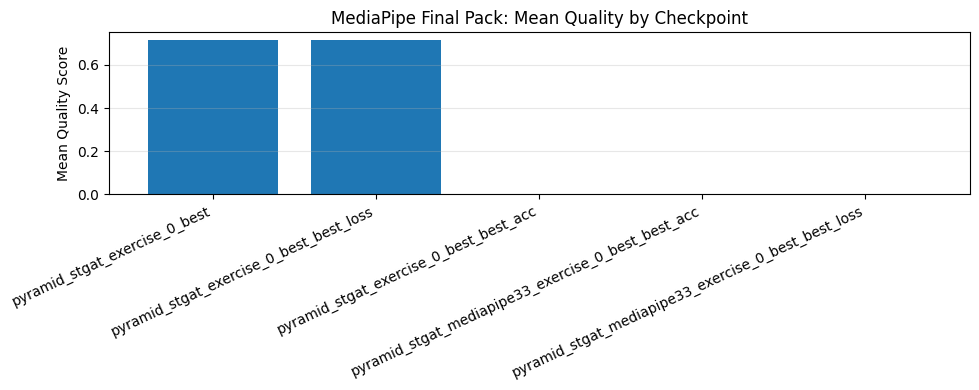

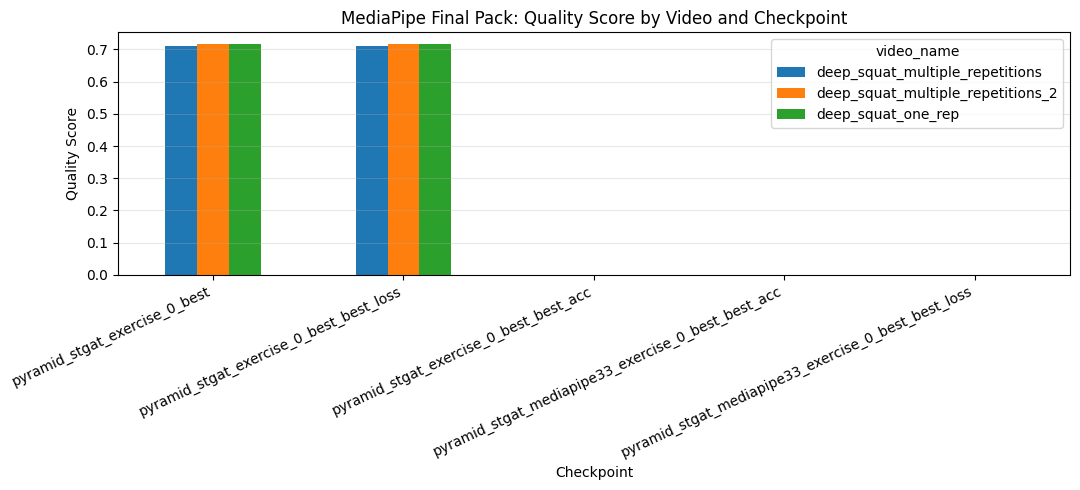

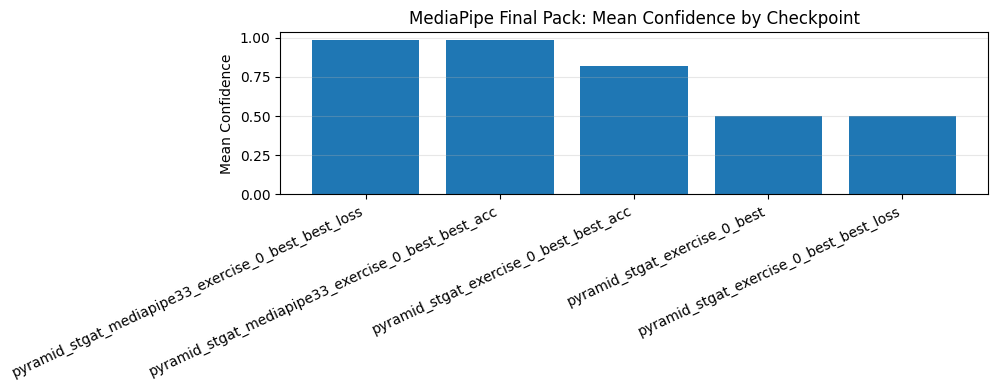

Loaded:
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\outputs\video_assessment\deep_squat_mediapipe_finalpack_summary.csv
- D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\outputs\video_assessment\deep_squat_mediapipe_finalpack_leaderboard.csv


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Resolve Backend root robustly from current notebook cwd
cwd = Path.cwd().resolve()
backend_root = cwd if cwd.name.lower() == "backend" else (cwd.parent if cwd.parent.name.lower() == "backend" else None)
if backend_root is None:
    raise RuntimeError(f"Could not locate Backend from cwd: {cwd}")

out_dir = backend_root / "temporal_pyramid_stgat" / "outputs" / "video_assessment"
summary_csv = out_dir / "deep_squat_mediapipe_finalpack_summary.csv"
leaderboard_csv = out_dir / "deep_squat_mediapipe_finalpack_leaderboard.csv"

if not summary_csv.exists() or not leaderboard_csv.exists():
    raise FileNotFoundError(
        "Expected CSVs not found. Please ensure these files exist:\n"
        f"- {summary_csv}\n- {leaderboard_csv}"
    )

summary_df = pd.read_csv(summary_csv)
leaderboard_df = pd.read_csv(leaderboard_csv)

display(summary_df.head())
display(leaderboard_df)

# 1) Mean quality score by checkpoint (leaderboard)
plt.figure(figsize=(10, 4))
plot_df = leaderboard_df.sort_values("mean_quality_score", ascending=False)
plt.bar(plot_df["checkpoint_name"], plot_df["mean_quality_score"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean Quality Score")
plt.title("MediaPipe Final Pack: Mean Quality by Checkpoint")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Per-video quality score lines across checkpoints
pivot_quality = summary_df.pivot_table(
    index="checkpoint_name",
    columns="video_name",
    values="quality_score_mean",
    aggfunc="mean",
)
pivot_quality = pivot_quality.loc[plot_df["checkpoint_name"]]

ax = pivot_quality.plot(kind="bar", figsize=(11, 5))
ax.set_title("MediaPipe Final Pack: Quality Score by Video and Checkpoint")
ax.set_xlabel("Checkpoint")
ax.set_ylabel("Quality Score")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Mean confidence by checkpoint
plt.figure(figsize=(10, 4))
plot_conf = leaderboard_df.sort_values("mean_confidence", ascending=False)
plt.bar(plot_conf["checkpoint_name"], plot_conf["mean_confidence"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean Confidence")
plt.title("MediaPipe Final Pack: Mean Confidence by Checkpoint")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Loaded:")
print(f"- {summary_csv}")
print(f"- {leaderboard_csv}")

Using checkpoint: D:\Programming\KinetoCheck\Backend\temporal_pyramid_stgat\weights\pyramid_stgat_exercise_0_best.pt
Checkpoint angle input width: 117
Loaded keys: 176 | Skipped incompatible keys: 0
Missing keys after partial load: 0 | Unexpected keys: 0
Using sample index: 0 | label: 0


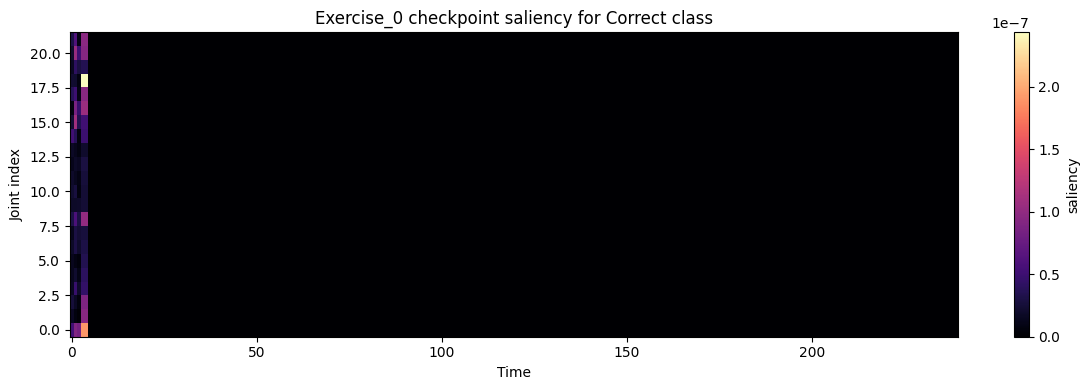

Top influential joints: [0, 18, 20, 16, 8, 21, 17, 15]
Joint saliency scores: [2.544565225193196e-09, 2.240897245542328e-09, 1.5050082291523381e-09, 1.4701297956776216e-09, 1.3444220181568767e-09, 1.2193058784859545e-09, 1.2006007299447674e-09, 1.1289306156569978e-09]


In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import types
import importlib.util

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Resolve an exercise_0 checkpoint
ckpt_path = None

if "all_models_df" in globals() and len(all_models_df) > 0:
    valid = all_models_df[all_models_df["accuracy"].notna()]
    if len(valid) > 0:
        ckpt_path = Path(
            valid.sort_values(["accuracy", "f1_incorrect_class"], ascending=False).iloc[0]["checkpoint"]
        )

if ckpt_path is None and "ckpts" in globals() and len(ckpts) > 0:
    ckpt_path = sorted([Path(p) for p in ckpts])[0]

if ckpt_path is None:
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents[:3]]
    found = []
    seen = set()
    for root in search_roots:
        for p in root.rglob("pyramid_stgat*exercise_0*.pt"):
            rp = p.resolve()
            if rp not in seen:
                found.append(rp)
                seen.add(rp)
    if not found:
        raise FileNotFoundError("No exercise_0 checkpoint found.")
    ckpt_path = sorted(found)[0]

print("Using checkpoint:", ckpt_path)

# 2) Bootstrap module path expected by checkpoint pickle: temporal_pyramid_stgat.config
cwd = Path.cwd().resolve()
backend_root = cwd if cwd.name.lower() == "backend" else (cwd.parent if cwd.parent.name.lower() == "backend" else None)
if backend_root is None:
    for p in [cwd, *cwd.parents[:5]]:
        candidate = p / "Backend"
        if candidate.exists() and candidate.is_dir():
            backend_root = candidate.resolve()
            break
if backend_root is None:
    raise RuntimeError(f"Could not locate Backend root from cwd: {cwd}")

pkg_name = "temporal_pyramid_stgat"
cfg_mod_name = "temporal_pyramid_stgat.config"
pkg_path = backend_root / "temporal_pyramid_stgat"
cfg_path = pkg_path / "config.py"

if str(backend_root) not in sys.path:
    sys.path.insert(0, str(backend_root))

if cfg_path.exists():
    if pkg_name not in sys.modules:
        pkg = types.ModuleType(pkg_name)
        pkg.__path__ = [str(pkg_path)]
        sys.modules[pkg_name] = pkg
    if cfg_mod_name not in sys.modules:
        spec = importlib.util.spec_from_file_location(cfg_mod_name, str(cfg_path))
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules[cfg_mod_name] = mod

# 3) Load checkpoint payload
payload = torch.load(ckpt_path, map_location=device, weights_only=False)

if isinstance(payload, dict) and "model_state" in payload:
    state = payload["model_state"]
    hidden_channels = int(payload.get("hidden_channels", 64))
elif isinstance(payload, dict):
    state = payload
    hidden_channels = 64
else:
    raise RuntimeError("Unsupported checkpoint payload type.")

# Infer expected angle feature width directly from checkpoint tensor shape
if "angle_proj.weight" not in state:
    raise RuntimeError("Checkpoint missing angle_proj.weight; cannot infer angle feature width.")
angle_in_features_ckpt = int(state["angle_proj.weight"].shape[1])
print("Checkpoint angle input width:", angle_in_features_ckpt)

# Build model with notebook architecture, then align angle projection width to checkpoint
model_ckpt = TemporalPyramidSTGAT(
    in_channels_coord=3,
    in_channels_angle=int(max(1, angle_in_features_ckpt // 22)),
    hidden_channels=hidden_channels,
    num_heads=4,
    num_joints=22,
    num_scales=len(cfg.temporal_scales),
    scales=list(cfg.temporal_scales),
    dropout=0.3,
    embedding_dim=128,
    use_triplet_loss=cfg.use_triplet,
).to(device)

if model_ckpt.angle_proj.in_features != angle_in_features_ckpt:
    model_ckpt.angle_proj = torch.nn.Linear(angle_in_features_ckpt, hidden_channels).to(device)

# Safe partial load: keep only keys that exist and match shape
model_state = model_ckpt.state_dict()
compatible = {}
skipped = []
for k, v in state.items():
    if k in model_state and model_state[k].shape == v.shape:
        compatible[k] = v
    else:
        skipped.append(k)

missing, unexpected = model_ckpt.load_state_dict(compatible, strict=False)
model_ckpt.eval()
print("Loaded keys:", len(compatible), "| Skipped incompatible keys:", len(skipped))
print("Missing keys after partial load:", len(missing), "| Unexpected keys:", len(unexpected))

# 4) Pick a correct-labeled sample from Deep Squat subset if available (exercise_id=1 in this parser)
ex_mask = (exercise_ids == 1) if "exercise_ids" in globals() else torch.ones_like(labels, dtype=torch.bool)
idx_candidates = torch.where((labels == 0) & ex_mask)[0]
if len(idx_candidates) == 0:
    raise RuntimeError("No correct sample found for chosen filter.")
idx = idx_candidates[0].item()
print("Using sample index:", idx, "| label:", int(labels[idx]))

# Build angle tensor with checkpoint-expected width
a_src = angles[idx:idx+1].to(device)
if a_src.shape[-1] > angle_in_features_ckpt:
    a = a_src[..., :angle_in_features_ckpt]
elif a_src.shape[-1] < angle_in_features_ckpt:
    pad = torch.zeros((a_src.shape[0], a_src.shape[1], angle_in_features_ckpt - a_src.shape[-1]), device=device, dtype=a_src.dtype)
    a = torch.cat([a_src, pad], dim=-1)
else:
    a = a_src

# 5) Gradient saliency wrt correct class logit
x = coords[idx:idx+1].to(device).clone().detach().requires_grad_(True)   # (1,T,J,3)
pyramid = create_pyramid_batch(x, scales=cfg.temporal_scales)
pyramid = {k: v.to(device) for k, v in pyramid.items()}

model_ckpt.zero_grad(set_to_none=True)
with torch.backends.cudnn.flags(enabled=False):
    out = model_ckpt(pyramid, a)
    correct_logit = out["logits"][0, 0]   # class 0 = correct
    correct_logit.backward()

# saliency: (T,J), averaged over xyz
sal = x.grad.detach().abs().mean(dim=-1).squeeze(0)

# 6) Plot heatmap
plt.figure(figsize=(12, 4))
plt.imshow(sal.cpu().numpy().T, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="saliency")
plt.xlabel("Time")
plt.ylabel("Joint index")
plt.title("Exercise_0 checkpoint saliency for Correct class")
plt.tight_layout()
plt.show()

# 7) Quick top-joint summary
joint_score = sal.mean(dim=0)
top_vals, top_idx = torch.topk(joint_score, k=min(8, joint_score.numel()))
print("Top influential joints:", top_idx.tolist())
print("Joint saliency scores:", [float(v) for v in top_vals])

Selected sample index for IG: 242


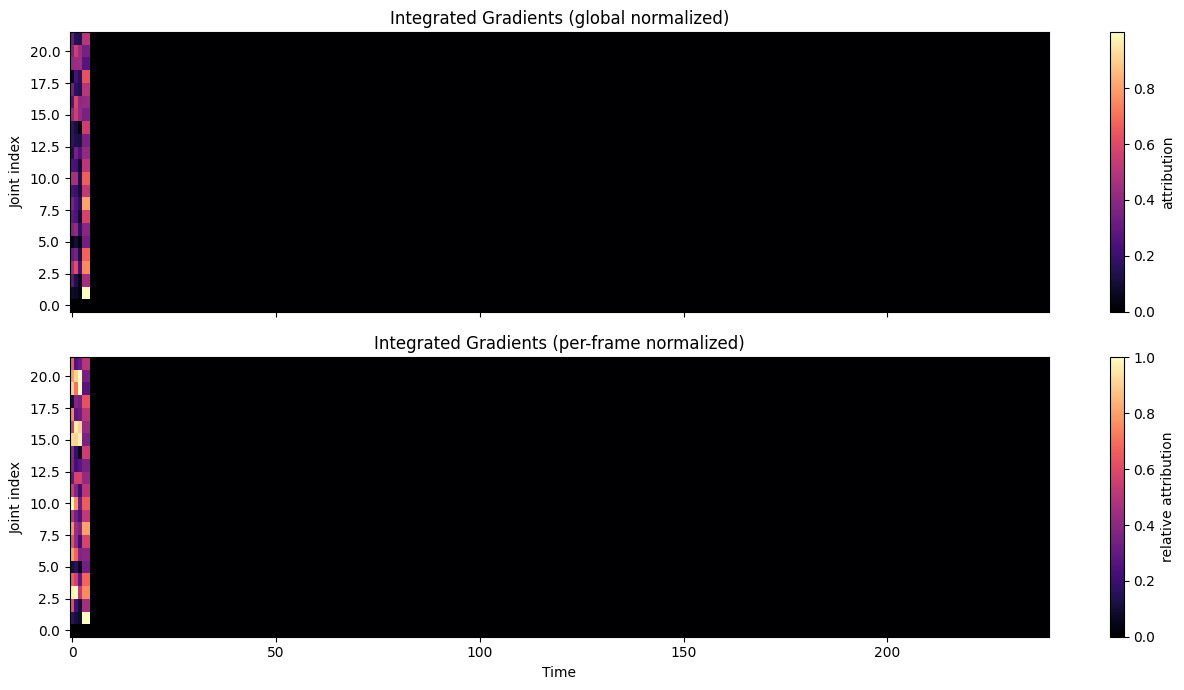

C:\Users\alexe\AppData\Local\Temp\ipykernel_79164\2336488193.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


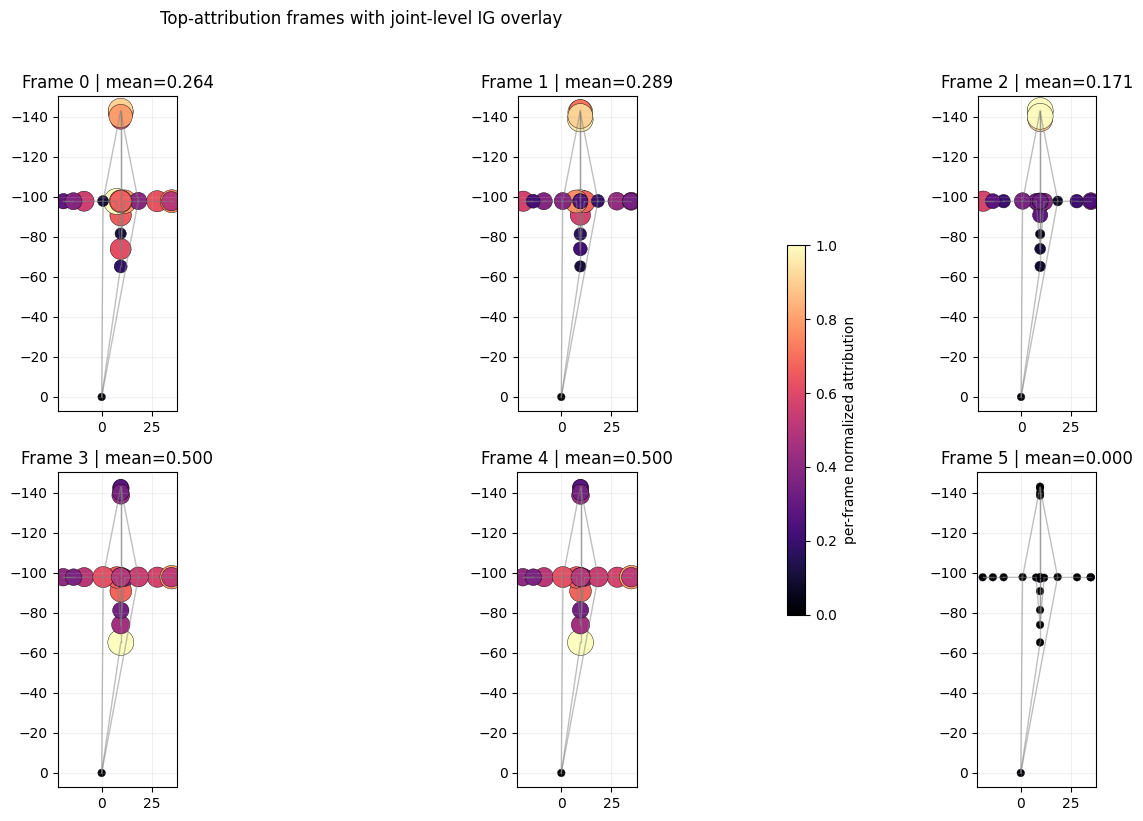

Top IG joints: [3, 8, 10, 1, 4, 15, 16, 20]
IG scores: [0.011669615283608437, 0.009938807226717472, 0.009931553155183792, 0.009119017980992794, 0.008855525404214859, 0.00884972233325243, 0.008722762577235699, 0.008525543846189976]


In [24]:
# Integrated Gradients + cleaner visualization (harder correct sample + skeleton overlay)
import numpy as np
import torch
import matplotlib.pyplot as plt

required = ["model_ckpt", "coords", "angles", "labels", "create_pyramid_batch"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run Cell 25 first.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ckpt.eval()

# Use Deep Squat subset if exercise_ids exists (exercise_id=1 in this notebook parser)
if "exercise_ids" in globals():
    mask_subset = (exercise_ids == 1) & (labels == 0)
else:
    mask_subset = (labels == 0)

candidate_idx = torch.where(mask_subset)[0]
if len(candidate_idx) == 0:
    raise RuntimeError("No candidate correct samples found for IG analysis.")

# Match angle width to checkpoint/model input
angle_in_features = int(model_ckpt.angle_proj.in_features)
def prepare_angles(a_src: torch.Tensor, target_dim: int) -> torch.Tensor:
    if a_src.shape[-1] > target_dim:
        return a_src[..., :target_dim]
    if a_src.shape[-1] < target_dim:
        pad = torch.zeros(
            (a_src.shape[0], a_src.shape[1], target_dim - a_src.shape[-1]),
            device=a_src.device, dtype=a_src.dtype
        )
        return torch.cat([a_src, pad], dim=-1)
    return a_src

# Pick a harder correct sample: correct label with lowest predicted correct-class probability
with torch.no_grad():
    sample_scores = []
    for idx_t in candidate_idx[: min(128, len(candidate_idx))]:
        x_tmp = coords[idx_t:idx_t+1].to(device)
        a_tmp = prepare_angles(angles[idx_t:idx_t+1].to(device), angle_in_features)
        pyr = create_pyramid_batch(x_tmp, scales=cfg.temporal_scales)
        pyr = {k: v.to(device) for k, v in pyr.items()}
        out_tmp = model_ckpt(pyr, a_tmp)
        prob_correct = torch.softmax(out_tmp["logits"], dim=1)[0, 0].item()
        pred = int(out_tmp["predictions"][0].item())
        if pred == 0:
            sample_scores.append((float(prob_correct), int(idx_t.item())))

if sample_scores:
    sample_scores.sort(key=lambda x: x[0])  # lowest confidence first
    _, idx = sample_scores[0]
else:
    # fallback to first correct-labeled sample
    idx = int(candidate_idx[0].item())

print(f"Selected sample index for IG: {idx}")

x0 = coords[idx:idx+1].to(device).detach()  # (1,T,J,3)
a0 = prepare_angles(angles[idx:idx+1].to(device), angle_in_features)

# Integrated Gradients settings
steps = 48
baseline = torch.zeros_like(x0)

# Accumulate gradients along straight-line path baseline -> input
total_grad = torch.zeros_like(x0)
for alpha in torch.linspace(0.0, 1.0, steps, device=device):
    x_alpha = (baseline + alpha * (x0 - baseline)).clone().detach().requires_grad_(True)
    pyr_alpha = create_pyramid_batch(x_alpha, scales=cfg.temporal_scales)
    pyr_alpha = {k: v.to(device) for k, v in pyr_alpha.items()}

    model_ckpt.zero_grad(set_to_none=True)
    with torch.backends.cudnn.flags(enabled=False):
        out_alpha = model_ckpt(pyr_alpha, a0)
        score = out_alpha["logits"][0, 0]  # Correct class logit
        score.backward()

    total_grad += x_alpha.grad.detach()

avg_grad = total_grad / float(steps)
ig = (x0 - baseline) * avg_grad  # (1,T,J,3)

# Attribution maps
ig_abs = ig.abs().mean(dim=-1).squeeze(0)  # (T,J)
ig_np = ig_abs.detach().cpu().numpy()

# Global normalization
eps = 1e-12
ig_global = ig_np / (ig_np.max() + eps)

# Per-frame normalization (highlights spatial focus each frame)
frame_max = np.maximum(ig_np.max(axis=1, keepdims=True), eps)
ig_frame_norm = ig_np / frame_max

# Plot 1: two heatmaps
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

im0 = axes[0].imshow(ig_global.T, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("Integrated Gradients (global normalized)")
axes[0].set_ylabel("Joint index")
fig.colorbar(im0, ax=axes[0], label="attribution")

im1 = axes[1].imshow(ig_frame_norm.T, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Integrated Gradients (per-frame normalized)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Joint index")
fig.colorbar(im1, ax=axes[1], label="relative attribution")

plt.tight_layout()
plt.show()

# Plot 2: skeleton overlay for top-attribution frames
if "UIPRMD_EDGES" in globals():
    edges = UIPRMD_EDGES
else:
    edges = []

seq = x0.squeeze(0).detach().cpu().numpy()  # (T,J,3)
frame_scores = ig_global.mean(axis=1)
k_frames = min(6, seq.shape[0])
top_frame_idx = np.argsort(-frame_scores)[:k_frames]
top_frame_idx = np.sort(top_frame_idx)

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i in range(rows * cols):
    ax = axes[i]
    if i >= len(top_frame_idx):
        ax.axis("off")
        continue

    t = int(top_frame_idx[i])
    xy = seq[t, :, :2]
    js = ig_frame_norm[t]

    # Draw edges first
    for s, d in edges:
        if s < xy.shape[0] and d < xy.shape[0]:
            ax.plot([xy[s, 0], xy[d, 0]], [xy[s, 1], xy[d, 1]], color="gray", alpha=0.5, linewidth=1)

    # Draw joints (color and size from attribution)
    sizes = 30.0 + 320.0 * js
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=js, s=sizes, cmap="magma", vmin=0.0, vmax=1.0, edgecolors="black", linewidths=0.3)

    # Invert y-axis for a more natural pose view in image coordinates
    ax.invert_yaxis()
    ax.set_title(f"Frame {t} | mean={frame_scores[t]:.3f}")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)

fig.suptitle("Top-attribution frames with joint-level IG overlay", y=1.02)
fig.colorbar(sc, ax=axes.tolist(), shrink=0.6, label="per-frame normalized attribution")
plt.tight_layout()
plt.show()

# Print top joints summary from IG
joint_score = ig_global.mean(axis=0)
top_j = np.argsort(-joint_score)[: min(8, joint_score.shape[0])]
print("Top IG joints:", top_j.tolist())
print("IG scores:", [float(joint_score[j]) for j in top_j])